In [3]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sys
!{sys.executable} -m pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import kagglehub
import pandas as pd
import os

# Télécharge le dataset dans un dossier local
chemin = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Fichiers téléchargés dans :", chemin)
print(os.listdir(chemin))

# Lecture avec encodage latin-1
orders    = pd.read_csv(os.path.join(chemin, "olist_orders_dataset.csv"), encoding='latin-1')
reviews   = pd.read_csv(os.path.join(chemin, "olist_order_reviews_dataset.csv"), encoding='latin-1')
customers = pd.read_csv(os.path.join(chemin, "olist_customers_dataset.csv"), encoding='latin-1')

print(orders.shape, reviews.shape, customers.shape)

100%|██████████| 42.6M/42.6M [00:50<00:00, 892kB/s] 

Extracting files...


Fichiers téléchargés dans : C:\Users\DELL\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']
(99441, 8) (99224, 7) (99441, 5)


In [9]:
# Exercice 1 — Formuler votre question métier
# Question retenue : Un retard de livraison fait-il baisser la note de satisfaction, et de combien de points en moyenne ?

# Pourquoi elle est actionnable : si le lien est confirmé avec un écart chiffré, la direction logistique peut prioriser 
# les investissements (entrepôts régionaux, partenariats transporteurs) sur les zones où les retards sont les plus fréquents, 
# en sachant combien de points de satisfaction chaque jour de retard coûte.

In [10]:
# Exercice 2 — Construire le jeu de données de travail
# 1) Filtrer orders : commandes livrées avec date de livraison renseignée
orders['order_purchase_timestamp']       = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date']  = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']  = pd.to_datetime(orders['order_estimated_delivery_date'])

orders_livrees = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notna())
].copy()

# 2) Fusion avec reviews 
reviews_dedup = reviews.drop_duplicates(subset='order_id', keep='first')

df = orders_livrees.merge(
    reviews_dedup[['order_id', 'review_score']], on='order_id', how='left'
)

# 3) Fusion avec customers
df = df.merge(
    customers[['customer_id', 'customer_state']], on='customer_id', how='left'
)

# 4) Feature engineering
df['delai_reel'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['retard']     = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['en_retard']  = df['retard'] > 0

# 5) Tranches de délai
bins   = [0, 5, 10, 15, 20, np.inf]
labels = ['0-5 j', '6-10 j', '11-15 j', '16-20 j', '> 20 j']
df['tranche_delai'] = pd.cut(df['delai_reel'], bins=bins, labels=labels, right=True)

print(df.shape)
print(df[['order_id', 'customer_state', 'delai_reel', 'retard', 'review_score', 'tranche_delai']].head())

(96470, 14)
                           order_id customer_state  delai_reel  retard  \
0  e481f51cbdc54678b7cc49136f2d6af7             SP           8      -8   
1  53cdb2fc8bc7dce0b6741e2150273451             BA          13      -6   
2  47770eb9100c2d0c44946d9cf07ec65d             GO           9     -18   
3  949d5b44dbf5de918fe9c16f97b45f8a             RN          13     -13   
4  ad21c59c0840e6cb83a9ceb5573f8159             SP           2     -10   

   review_score tranche_delai  
0           4.0        6-10 j  
1           4.0       11-15 j  
2           5.0        6-10 j  
3           5.0       11-15 j  
4           5.0         0-5 j  


In [11]:
# Exercice 3 — Vérifier la qualité
# Statistiques sur le délai réel
print(df['delai_reel'].describe())

# Commandes en retard
pct_retard = df['en_retard'].mean()
print(f"\nPourcentage de commandes en retard : {pct_retard:.2%}")

# Valeurs extrêmes
print(f"\nDélai max : {df['delai_reel'].max()} jours")
print(f"Nombre de commandes > 100 jours : {(df['delai_reel'] > 100).sum()}")
print(f"Nombre de commandes > 200 jours : {(df['delai_reel'] > 200).sum()}")

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delai_reel, dtype: float64

Pourcentage de commandes en retard : 6.77%

Délai max : 209 jours
Nombre de commandes > 100 jours : 63
Nombre de commandes > 200 jours : 2


en_retard
False    4.290721
True     2.271588
Name: review_score, dtype: float64
                   mean  count
tranche_delai                 
0-5 j          4.431639  19141
6-10 j         4.348203  32685
11-15 j        4.246471  21037
16-20 j        4.092328  10636
> 20 j         3.119639  12312


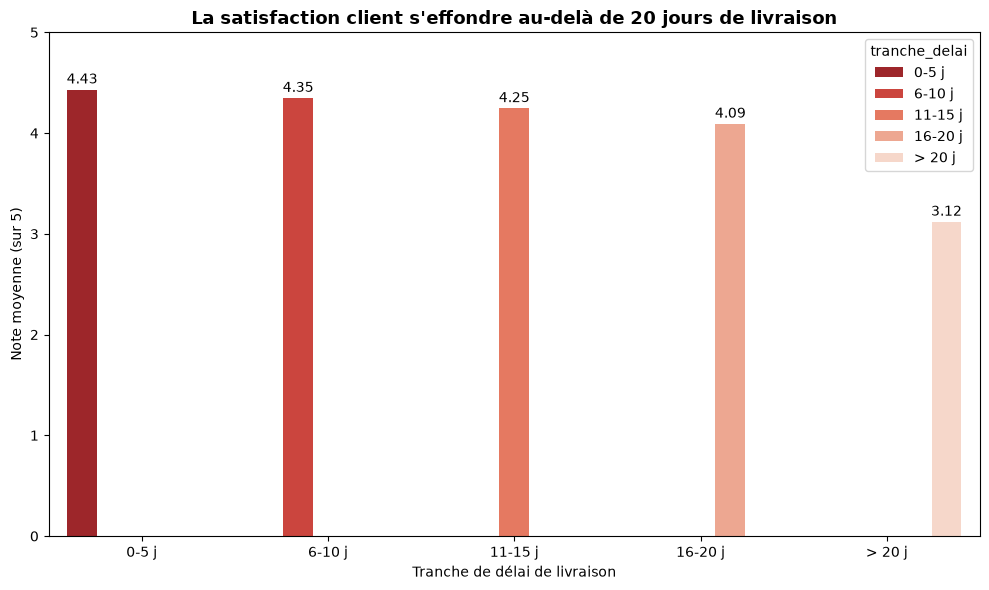

In [22]:
# Exercice 4 — Le retard fait-il chuter la satisfaction ?
# Comparaison à temps vs en retard
note_par_retard = df.groupby('en_retard')['review_score'].mean()
print(note_par_retard)

# Par tranche de délai
note_par_tranche = df.groupby('tranche_delai', observed=True)['review_score'].agg(['mean', 'count'])
print(note_par_tranche)

# Graphique
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df, x='tranche_delai', y='review_score', hue='tranche_delai',
    estimator='mean', errorbar=None, palette='Reds_r', ax=ax
)
ax.set_title("La satisfaction client s'effondre au-delà de 20 jours de livraison",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Tranche de délai de livraison")
ax.set_ylabel("Note moyenne (sur 5)")
ax.set_ylim(0, 5)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2)
plt.tight_layout()
plt.show()

                delai_moyen  nb_commandes
customer_state                           
BA                18.866400          3256
ES                15.331830          1995
GO                15.150741          1957
RJ                14.848583         12350
RS                14.819237          5344
SC                14.475183          3546
DF                12.509135          2080
MG                11.542188         11354
PR                11.526711          4923
SP                 8.298094         40494


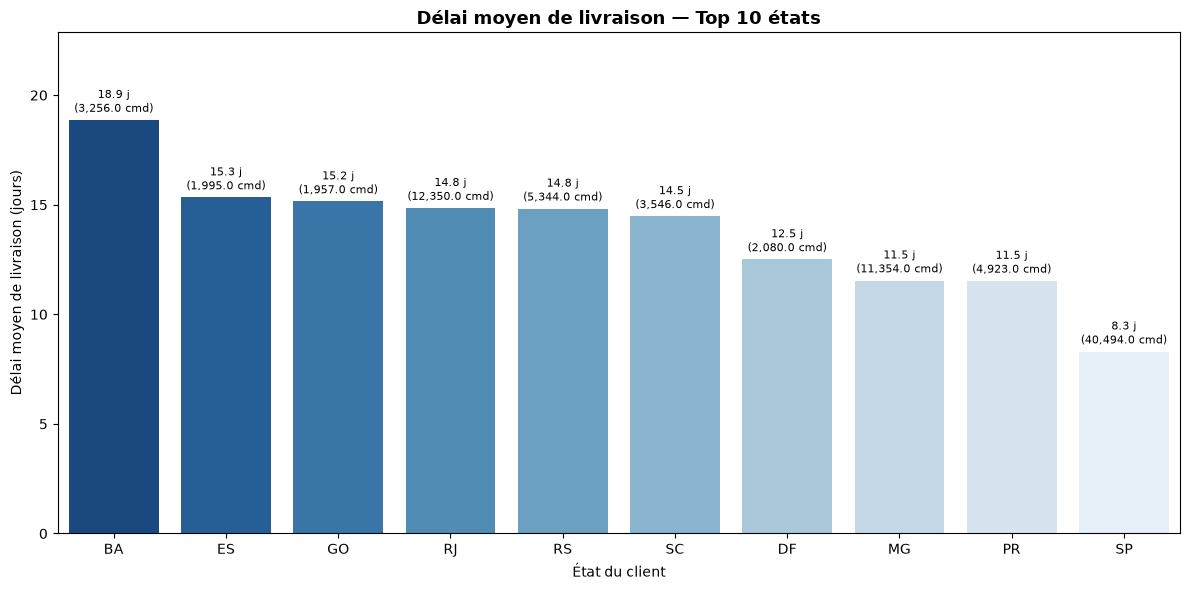

In [23]:
# Exercice 5 — Où les délais sont-ils les plus longs ?

# Top 10 états par nombre de commandes
top10_etats = df['customer_state'].value_counts().nlargest(10).index

# Délai moyen par état
delai_par_etat = (
    df[df['customer_state'].isin(top10_etats)]
      .groupby('customer_state')
      .agg(
          delai_moyen=('delai_reel', 'mean'),
          nb_commandes=('order_id', 'count')
      )
      .sort_values('delai_moyen', ascending=False)
)

print(delai_par_etat)

# --------------------------------------------------
# Graphique
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Correction du FutureWarning Seaborn :
# on utilise hue + legend=False
sns.barplot(
    data=delai_par_etat.reset_index(),
    x='customer_state',
    y='delai_moyen',
    hue='customer_state',
    palette='Blues_r',
    legend=False,
    ax=ax
)

# Titres et axes
ax.set_title(
    "Délai moyen de livraison — Top 10 états",
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel("État du client")
ax.set_ylabel("Délai moyen de livraison (jours)")

# --------------------------------------------------
# Ajouter les annotations sur chaque barre
# --------------------------------------------------
for bar, (_, row) in zip(ax.patches, delai_par_etat.iterrows()):

    hauteur = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        hauteur + 0.2,
        f"{row['delai_moyen']:.1f} j\n({row['nb_commandes']:,} cmd)",
        ha='center',
        va='bottom',
        fontsize=8
    )

# Ajouter un peu d'espace au-dessus des barres
ax.set_ylim(0, delai_par_etat['delai_moyen'].max() + 4)

plt.tight_layout()
plt.show()

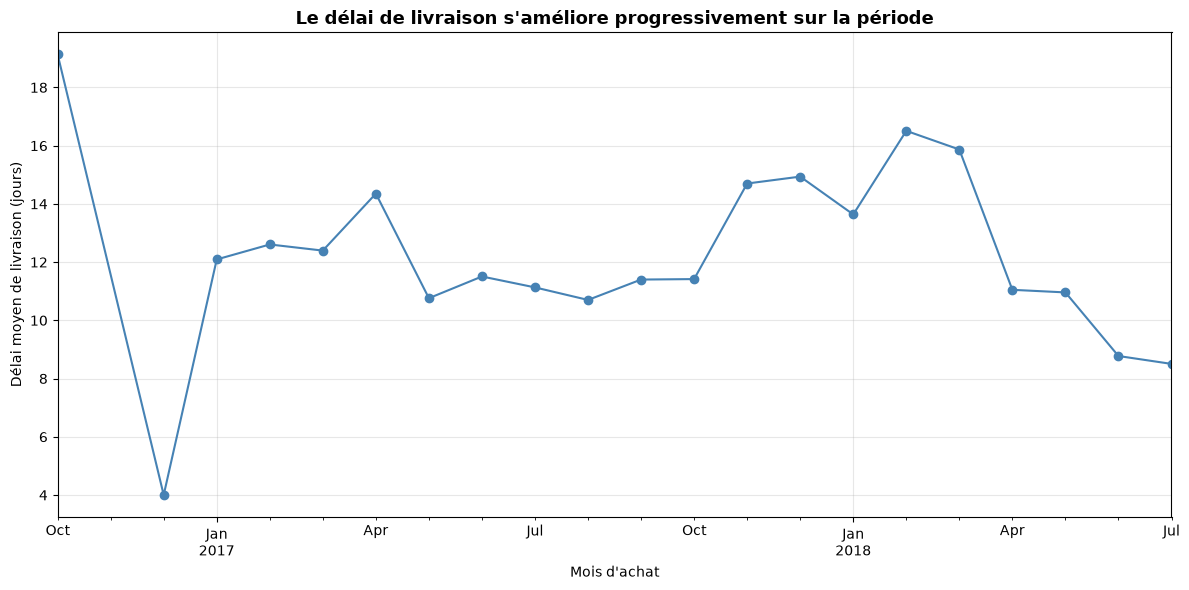

In [14]:
# Exercice 6 — L'évolution du délai dans le temps
# Regroupement par mois d'achat
df['mois_achat'] = df['order_purchase_timestamp'].dt.to_period('M')
delai_mensuel = df.groupby('mois_achat')['delai_reel'].mean()

# Exclusion des mois incomplets (premier et dernier)
delai_mensuel = delai_mensuel.iloc[1:-1]

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))
delai_mensuel.plot(kind='line', marker='o', color='steelblue', ax=ax)
ax.set_title("Le délai de livraison s'améliore progressivement sur la période",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Mois d'achat")
ax.set_ylabel("Délai moyen de livraison (jours)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

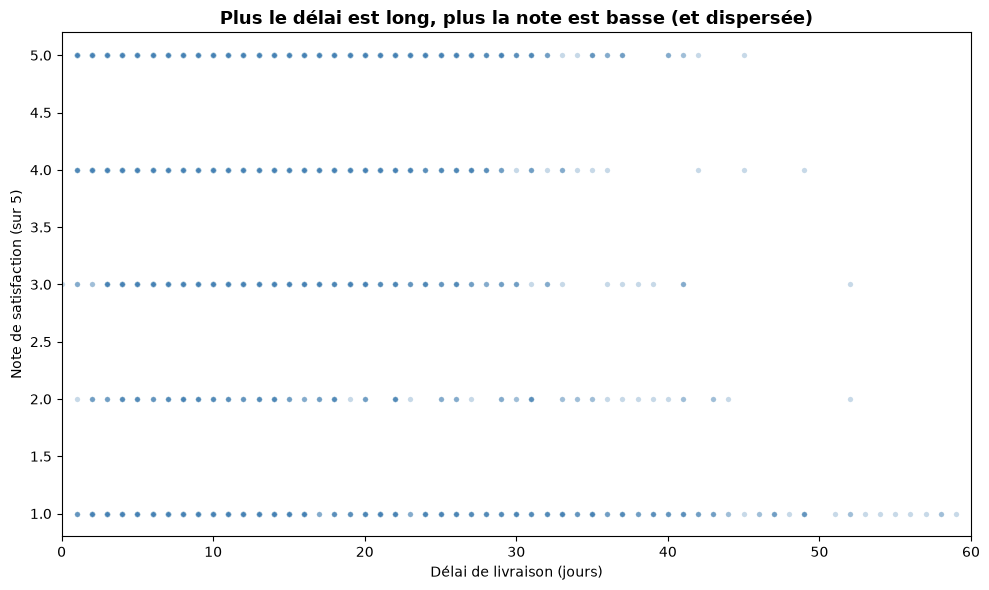

In [15]:
# Exercice 7 — Un lien statistique visible
# Nuage de points — version lisible (échantillonnage + transparence)
df_sample = df.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_sample, x='delai_reel', y='review_score',
    alpha=0.3, s=15, color='steelblue', ax=ax
)
ax.set_title("Plus le délai est long, plus la note est basse (et dispersée)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Délai de livraison (jours)")
ax.set_ylabel("Note de satisfaction (sur 5)")
ax.set_xlim(0, 60)
plt.tight_layout()
plt.show()

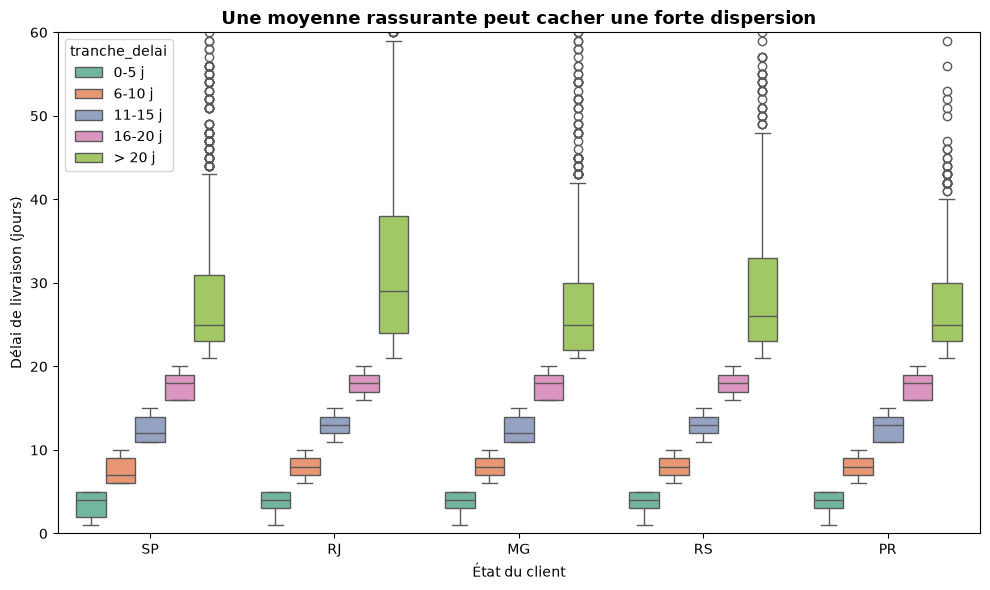

In [21]:
# Exercice 8 — La dispersion des délais
top5_etats = df['customer_state'].value_counts().nlargest(5).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df[df['customer_state'].isin(top5_etats)],
    x='customer_state', y='delai_reel', hue='tranche_delai',
    order=top5_etats, palette='Set2', ax=ax
)
ax.set_title("Une moyenne rassurante peut cacher une forte dispersion",
             fontsize=13, fontweight='bold')
ax.set_xlabel("État du client")
ax.set_ylabel("Délai de livraison (jours)")
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

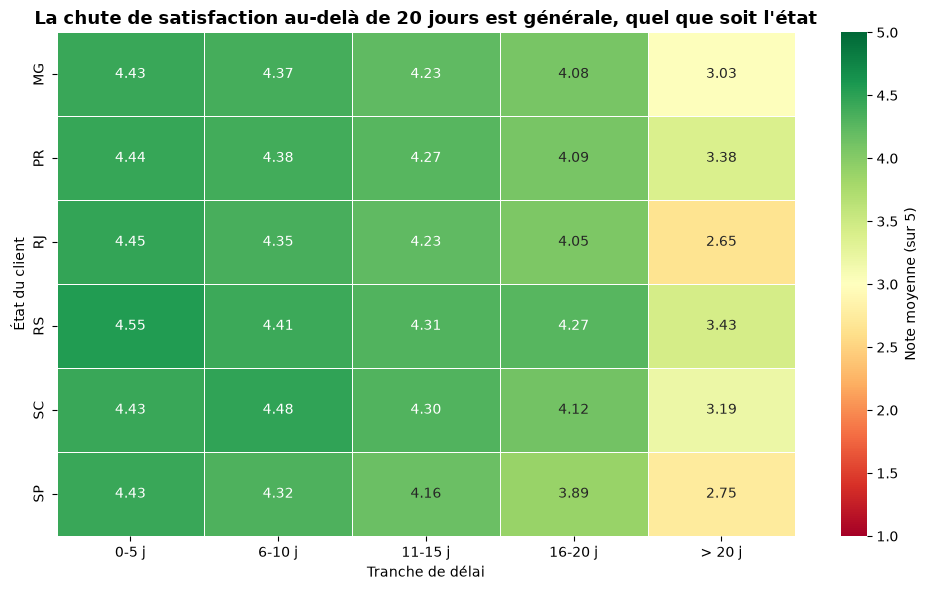

In [17]:
# Exercice 9 — Une vue d'ensemble croisée
top_etats = df['customer_state'].value_counts().nlargest(6).index

pivot = df[df['customer_state'].isin(top_etats)].pivot_table(
    index='customer_state',
    columns='tranche_delai',
    values='review_score',
    aggfunc='mean',
    observed=True
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=1, vmax=5,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Note moyenne (sur 5)'}
)
ax.set_title("La chute de satisfaction au-delà de 20 jours est générale, quel que soit l'état",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Tranche de délai")
ax.set_ylabel("État du client")
plt.tight_layout()
plt.show()

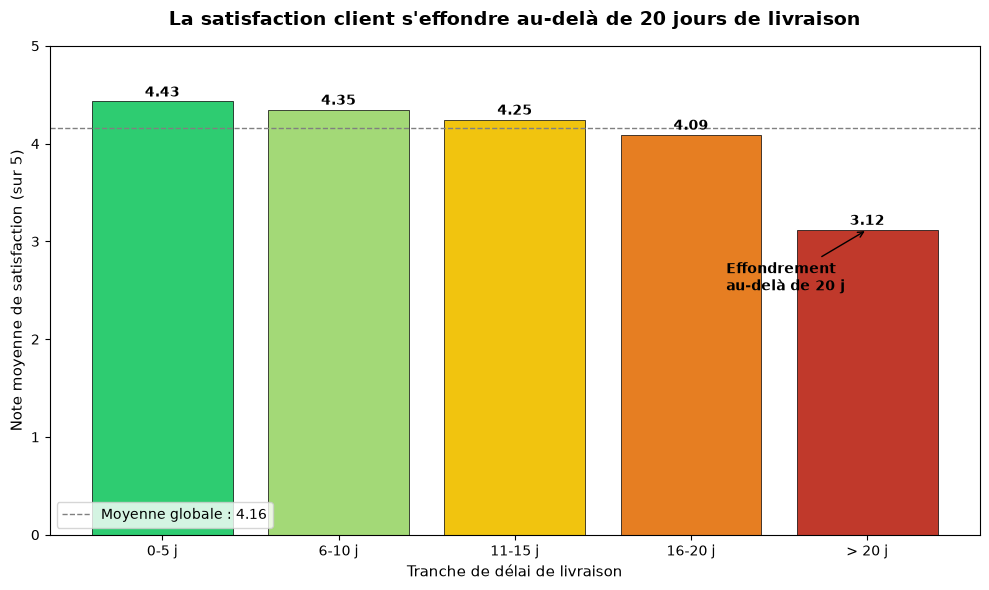

In [18]:
# Exercice 10 — Personnaliser pour un usage professionnel
fig, ax = plt.subplots(figsize=(10, 6))

data = df.groupby('tranche_delai', observed=True)['review_score'].mean().reset_index()
bars = ax.bar(data['tranche_delai'], data['review_score'],
              color=['#2ecc71', '#a3d977', '#f1c40f', '#e67e22', '#c0392b'],
              edgecolor='black', linewidth=0.5)

ax.set_title("La satisfaction client s'effondre au-delà de 20 jours de livraison",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Tranche de délai de livraison", fontsize=11)
ax.set_ylabel("Note moyenne de satisfaction (sur 5)", fontsize=11)
ax.set_ylim(0, 5)
ax.axhline(df['review_score'].mean(), color='gray', linestyle='--', linewidth=1,
           label=f"Moyenne globale : {df['review_score'].mean():.2f}")
ax.legend(loc='lower left')

for bar, val in zip(bars, data['review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontweight='bold')

ax.annotate("Effondrement\nau-delà de 20 j",
            xy=(4, data['review_score'].iloc[-1]),
            xytext=(3.2, 2.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

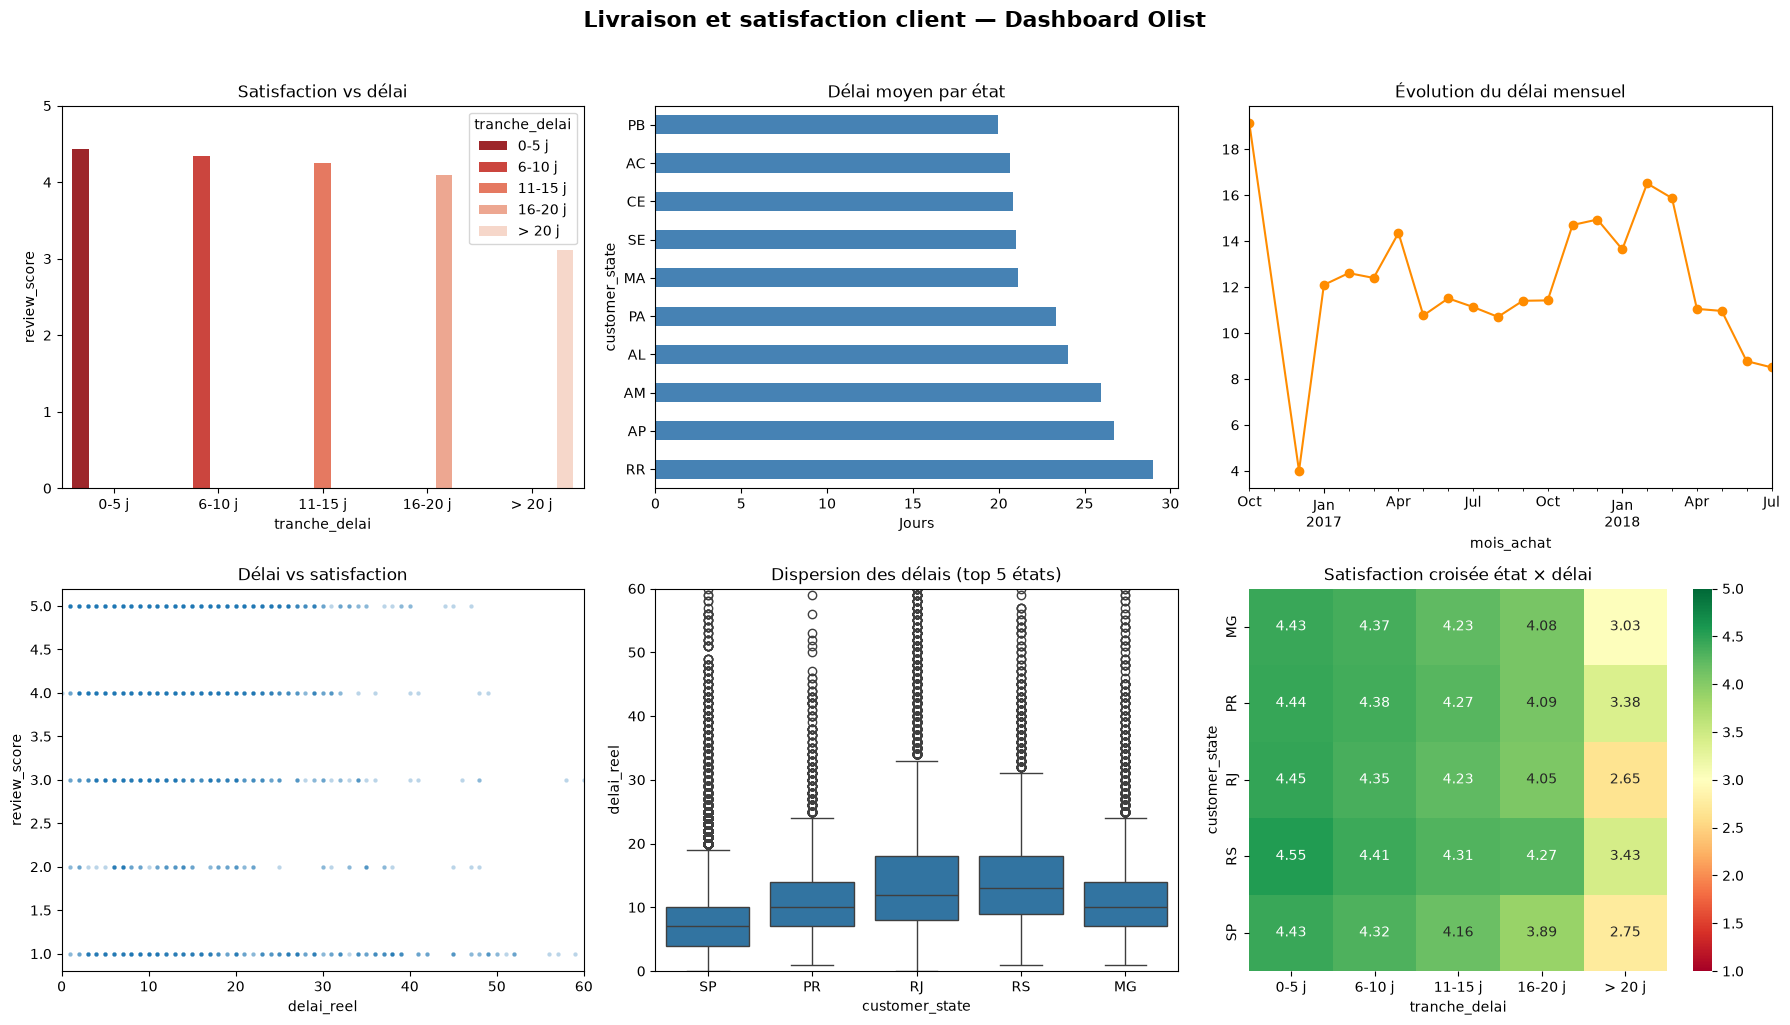

In [20]:
# Exercice 11 — Construire le dashboard de synthèse
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Livraison et satisfaction client — Dashboard Olist",
             fontsize=16, fontweight='bold', y=1.02)

# Panneau 1 — Satisfaction par tranche de délai
sns.barplot(data=df, x='tranche_delai', y='review_score', hue='tranche_delai',
            estimator='mean', errorbar=None, palette='Reds_r', ax=axes[0, 0])
axes[0, 0].set_title("Satisfaction vs délai")
axes[0, 0].set_ylim(0, 5)

# Panneau 2 — Délai moyen par état (top 10)
delai_etat = df.groupby('customer_state')['delai_reel'].mean().nlargest(10)
delai_etat.plot(kind='barh', color='steelblue', ax=axes[0, 1])
axes[0, 1].set_title("Délai moyen par état")
axes[0, 1].set_xlabel("Jours")

# Panneau 3 — Évolution mensuelle du délai
df.groupby('mois_achat')['delai_reel'].mean().iloc[1:-1].plot(
    kind='line', marker='o', color='darkorange', ax=axes[0, 2])
axes[0, 2].set_title("Évolution du délai mensuel")

# Panneau 4 — Nuage de points
sns.scatterplot(data=df.sample(3000), x='delai_reel', y='review_score',
                alpha=0.3, s=10, ax=axes[1, 0])
axes[1, 0].set_title("Délai vs satisfaction")
axes[1, 0].set_xlim(0, 60)

# Panneau 5 — Boxplot top 5 états
top5 = df['customer_state'].value_counts().nlargest(5).index
sns.boxplot(data=df[df['customer_state'].isin(top5)],
            x='customer_state', y='delai_reel', ax=axes[1, 1])
axes[1, 1].set_title("Dispersion des délais (top 5 états)")
axes[1, 1].set_ylim(0, 60)

# Panneau 6 — Heatmap
pivot = df[df['customer_state'].isin(top5)].pivot_table(
    index='customer_state', columns='tranche_delai',
    values='review_score', aggfunc='mean', observed=True)
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=1, vmax=5, ax=axes[1, 2])
axes[1, 2].set_title("Satisfaction croisée état × délai")

plt.tight_layout()
plt.savefig("dashboard_olist.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Exercice 12 — Restitution finale
Question posée : un retard de livraison fait-il baisser la satisfaction client, et de combien ?

Réponse : oui, et l'effet est massif. Les commandes livrées en 0-5 jours obtiennent une note moyenne de 4,4/5, contre 3,1/5 
pour celles livrées au-delà de 20 jours — soit une chute de 1,3 point. La dégradation est monotone : 4,4 → 4,3 → 4,2 → 4,1 → 3,1. 
La heatmap confirme que cette chute est générale, quel que soit l'état : à São Paulo comme au Rio Grande do Sul, la note tombe sous 3,0/5 
dès que le délai dépasse 20 jours. Géographiquement, les états du Nord et du Nordeste (PB, AC, CE, SE, MA, PA, AL, AM, AP) affichent des délais 
moyens de 20 à 29 jours, contre 8 jours à São Paulo : le volume (SP = plus de commandes) ne se confond pas avec la performance. La dispersion 
est également un facteur clé : le boxplot montre des écarts-types de 10 à 15 jours dans le top 5 des états, signe d'une expérience client très 
inégale. Enfin, la tendance mensuelle s'améliore sur 2018, avec un pic saisonnier en novembre 2017 (Black Friday). Recommandation : prioriser un 
investissement logistique dans le Nord/Nordeste et mettre en place une alerte automatique dès 15 jours de délai pour prévenir le client et limiter 
la chute de satisfaction.